In [7]:
import grid2op
import hydra
from hydra.utils import instantiate
from matplotlib import pyplot as plt

from common import GraphObservationSpace, EDGE_INDEX
from nri.train_nri import PlottingArgs
from visualization.utils import get_node_styles, visualize_graph

In [8]:
with hydra.initialize(config_path="../hydra_configs", version_base="1.3"):
    cfg = hydra.compose(config_name="config")

# prepare plotting args
env = grid2op.make(cfg.env.env_name)
observation_space: GraphObservationSpace = instantiate(cfg.nri.dataset_creation.obs_space, grid2op_observation_space=env.observation_space)
edge_index = observation_space.to_gym(env.reset())[EDGE_INDEX]

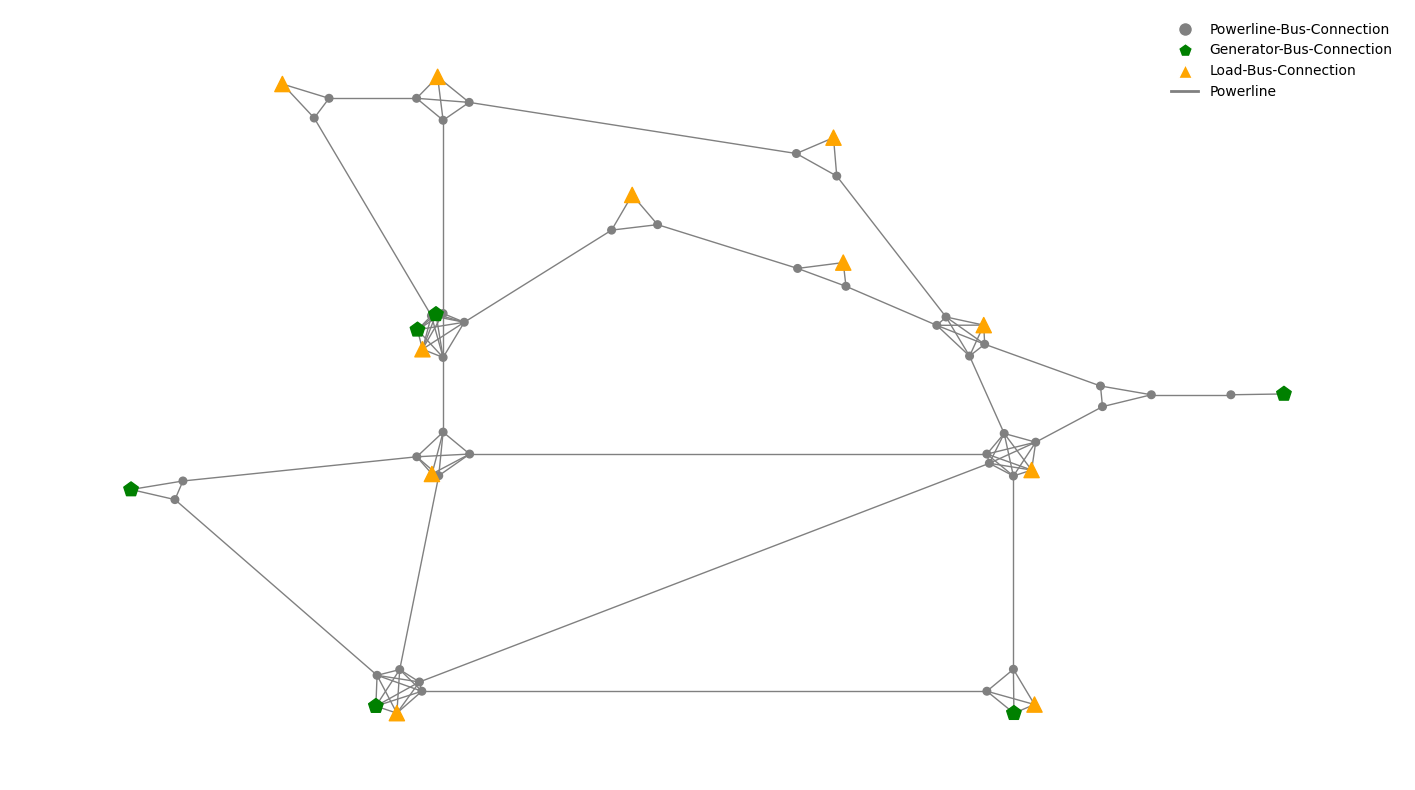

In [9]:
plotting_args = PlottingArgs(
    num_nodes=observation_space.num_nodes,
    node_styles=get_node_styles(env, observation_space.__class__),
    powerline_edge_index=edge_index
)
visualize_graph(plotting_args)
plt.show()